# Bottleneck study — constraints ∧ WAPE ∧ demand response (hist, Colab)

Runtime > Change runtime type > **GPU** (any). The repo ships the prepared data
(`data/preprocessed/hist/...`) and every pilot checkpoint (`weights/`), so cloning is
the whole setup. Scripts re-run from cached JSONs — a disconnect costs one cell.

**The three bottlenecks** (why this study exists):

1. model WAPE loses to 5-min persistence (0.1084)
2. the constrained models default to persistence and ignore a simulated load increase
   (RAYEN co-predicts its own demand `D_t`, so the balance plane never moves)
3. the battery/SOC constraint reads inconsistently (79% vs 115% vs 4220% "swing"
   for the same physics, depending only on the integration window)

## 1 · Metrics & evaluation

| what | metric | protocol |
| --- | --- | --- |
| accuracy | WAPE per-channel + macro, R² | teacher-forced full test (Jan–Jul 2026) |
| balance | `bal_own_max_mw`, mismatch % | teacher-forced + scenario rollout |
| ramp / box | `n_ramp` (free/seam/tf split), `n_neg` | closed-loop: stress episodes + free-window rollout |
| responsiveness | **response_capture** (fraction of simulated increase delivered), tracking p50/p95 | free-window closed-loop scenario rollout |
| battery | per-day SOC feasible %, worst-day % (whole-window swing reported for transparency only) | all protocols, unified |

Baselines every row must face: **persistence** (WAPE floor) and **anchor(persistence)**
(zero-parameter, structurally responsive).

## 2 · Solution ladders (A → B → C)

**P2 — respond to the simulated load increase** *(headline)*
A: pin `D = nd(t−1)` (`RayenHeadFixedD`) — the scenario `net_demand` is teacher-forced
into the free window, so the plane moves with the simulated demand and the fleet is
*forced* to follow within ramps. → B: retrain `*_rayenfd` (gas_steam passthrough on).
→ C: inference-only anchor (`anchor_persistence` row, always reported).

**P1 — WAPE parity with persistence**
A: freeze gas_steam at persistence (`passthrough`, zero-retrain buffer retrofit).
→ B: retrain. → C: accept macro gap, isolate it to the battery channels per-channel.

**P3 — battery constraint**
A: per-day SOC segmentation everywhere (batteries cycle daily; window-cumsum drift
was the artifact). → B: stateful closed-loop SOC clip. → C: recalibrate cap+η from
the telemetry subset.

Gates are computed by `constraints/study_report.py` → `study_verdicts.json`; the
conditional cells below read it.


In [1]:
REPO = "github.com/nm-quan/energy_modelling.git"
TOKEN = ""   # repo is PRIVATE: paste a fine-grained READ-ONLY token (Contents: read)
BRANCH = "claude/model-bottlenecks-constraints-gb1aoj"   # set to "main" once merged
import os
url = f"https://{TOKEN + '@' if TOKEN else ''}{REPO}"
if not os.path.exists("energy_modelling"):
    !git clone -q --branch $BRANCH $url
%cd energy_modelling
!git pull -q
!nvidia-smi -L


/content/energy_modelling
GPU 0: Tesla T4 (UUID: GPU-382f084f-77e6-a066-e2d6-6607c3868659)


In [2]:
# optional: mount Drive so retrained weights survive the VM
OUT = "/content/runs"
try:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT = "/content/drive/MyDrive/energy_runs"
except Exception as e:
    print("no Drive:", e)
os.makedirs(OUT, exist_ok=True)


Mounted at /content/drive


## 0 · Sanity — constraint layers are feasible at any weights


In [3]:
!python constraints/test_constraint_layers.py


test_dr_adversarial:
  DR/adversarial0 (alpha max 1.000): bal_max=0.0014 MW, ramp/floor OK (min P=33.3716)
  DR/adversarial1 (alpha max 1.000): bal_max=0.0014 MW, ramp/floor OK (min P=-0.0113)
  DR/adversarial2 (alpha max 1.000): bal_max=0.0010 MW, ramp/floor OK (min P=41.4069)
test_dr_noop_when_feasible:
  DR no-op: alpha_max=4.7e-06, max drift 6.77e-05
test_dr_random_weights:
  DR/lstm (alpha act 72%): bal_max=0.0010 MW, ramp/floor OK (min P=6.6867)
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
  DR/itransformer (alpha act 86%): bal_max=0.0011 MW, ramp/floor OK (min P=-0.0000)
test_lp_certificate:
  LP: t*=29.45 MW, mc_min_slack=29.45, mc_eq_max=4.1e-12
test_rayen_gradients:
  rayen gradients: 12/12 params nonzero
test_rayen_random_weights:
  rayen/lstm/s0: bal_max=0.0009 MW, ramp/floor OK (min P=0.4

## 1 · Pilot — ladder **A** for all three problems, no training

`eval_hist_models.py` runs the TF (balance/accuracy) + CL (stress-episode ramp)
tables over every checkpoint in `weights/`, now including `itransformer_rayenfd`
with the gas_steam passthrough retrofit (`+spt`, P1-A) and per-channel WAPE +
per-day SOC (P3-A) built in.


In [4]:
!python constraints/eval_hist_models.py --ckpt-dir weights
from IPython.display import Markdown, display
for t in ["hist_tf.md", "hist_tf_per_channel.md", "hist_cl_stress.md"]:
    display(Markdown(open(f"constraints/results/{t}").read()))


/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
  [skip] no checkpoint for lstm_rayenfd
  itransformer_rayenfd: legacy checkpoint, constructor buffers kept for ['_free', '_sign_free']
  lstm_task7+DR: safe LP t*=29.45 MW
  itransformer_task7+DR: safe LP t*=29.45 MW
models: ['persistence', 'lstm_rayen', 'itransformer_rayen', 'itransformer_rayenfd+spt', 'lstm_task7', 'lstm_task7+DR', 'itransformer_task7', 'itransformer_task7+DR']  device=cuda
  TF persistence            WAPE=0.1084 nd_WAPE=0.0182 bal_own=0.000 dem_act=47728 (1.82%) neg=0 ramp=0 soc_day=100%
  TF lstm_rayen             WAPE=0.1454 nd_WAPE=0.0181 bal_own=0.001 dem_act=47725 (1.81%) neg=0 ramp=0 soc_day=100%
  TF itransformer_rayen     WAPE=0.1292 nd_WAPE=0.0182 bal_own=0.002 dem_act=47768 (1.82%) neg=0 ramp=0 soc_day=100%
  TF itransformer_r

# Hist teacher-forced test (demand balance)

Test = Jan-Jul 2026 (stride 1). @own = vs the model's own D_t (mechanism check, threshold 10.0 MW); @act = vs actual nd(t). nd_WAPE = D_t forecast quality. SOC per calendar day, eta_rt=0.834, cap 4736 MWh.

| model | WAPE | R2 | nd_WAPE | bal_own_max_mw | n_demand_own | n_demand_act | mismatch_act_pct | n_neg | n_ramp_vs_prev | soc_day_feasible_pct | soc_worst_day_pct |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| persistence | 0.1084 | 0.9669 | 0.0182 | 0.0005 | 0 | 47728 | 1.8158 | 0 | 0 | 100.0 | 79.4 |
| lstm_rayen | 0.1454 | 0.9668 | 0.0181 | 0.0014 | 0 | 47725 | 1.8102 | 0 | 0 | 100.0 | 79.7 |
| itransformer_rayen | 0.1292 | 0.9674 | 0.0182 | 0.0017 | 0 | 47768 | 1.8176 | 0 | 0 | 100.0 | 76.9 |
| itransformer_rayenfd+spt | 0.1123 | 0.9676 | 0.0182 | 0.0014 | 0 | 47728 | 1.8158 | 0 | 0 | 100.0 | 76.2 |
| lstm_task7 | 0.2700 | 0.9431 | 0.0248 | 155.7 | 16593 | 48295 | 2.5054 | 55164 | 731 | 100.0 | 61.9 |
| lstm_task7+DR | 0.3201 | 0.8992 | 0.0287 | 0.0013 | 0 | 49212 | 2.8714 | 0 | 0 | 100.0 | 71.9 |
| itransformer_task7 | 0.1313 | 0.9683 | 0.0211 | 254.3 | 38496 | 48766 | 1.9774 | 35505 | 0 | 100.0 | 76.2 |
| itransformer_task7+DR | 0.2692 | 0.9299 | 0.0271 | 0.0016 | 0 | 49925 | 2.7052 | 0 | 0 | 100.0 | 77.2 |


# Hist teacher-forced per-channel WAPE

Same run as hist_tf.md. delta_vs_persistence = macro WAPE minus the persistence row's. Persistence is the h=1 floor; the study gate asks for parity (<= +0.005 macro) with the residual gap isolated to the battery channels.

| model | hydro | coal_brown | gas_steam | gas_ocgt | battery_charging | battery_discharging | macro_WAPE | delta_vs_persistence |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| persistence | 0.0533 | 0.0076 | 0.0360 | 0.0343 | 0.2493 | 0.2697 | 0.1084 | +0.0000 |
| lstm_rayen | 0.0581 | 0.0077 | 0.2402 | 0.0495 | 0.2499 | 0.2668 | 0.1454 | +0.0370 |
| itransformer_rayen | 0.0545 | 0.0085 | 0.1509 | 0.0450 | 0.2452 | 0.2714 | 0.1292 | +0.0209 |
| itransformer_rayenfd+spt | 0.0563 | 0.0090 | 0.0360 | 0.0549 | 0.2449 | 0.2730 | 0.1123 | +0.0040 |
| lstm_task7 | 0.1165 | 0.0146 | 0.7576 | 0.1382 | 0.2953 | 0.2976 | 0.2700 | +0.1616 |
| lstm_task7+DR | 0.1883 | 0.0139 | 0.5786 | 0.1943 | 0.4811 | 0.4647 | 0.3201 | +0.2117 |
| itransformer_task7 | 0.0777 | 0.0097 | 0.0852 | 0.0624 | 0.2628 | 0.2903 | 0.1313 | +0.0230 |
| itransformer_task7+DR | 0.1712 | 0.0108 | 0.3362 | 0.1782 | 0.4187 | 0.5001 | 0.2692 | +0.1608 |


# Hist closed-loop stress episodes (ramp rate)

Autoregressive rollout over TEST-split stress episodes; models feed back their own dispatch, exogenous features stay actual. Ramps on the model's own trajectory (asymmetric data limits + 0.6 MW tol); ramp_excess_pct = 100*sum(MW beyond limit)/sum(|pred|). SOC per episode.

| model | cl_WAPE | n_ramp | ramp_excess_pct | bal_own_max_mw | n_demand_act | mismatch_act_pct | n_neg | soc_feasible_eps | soc_worst_ep_pct |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| persistence | 0.7589 | 0 | 0.0000 | 0.0000 | 4286 | 23.5 | 0 | 12 | 239.4 |
| lstm_rayen | 0.7988 | 0 | 0.0000 | 0.0009 | 4273 | 23.3 | 0 | 14 | 111.1 |
| itransformer_rayen | 0.7642 | 0 | 0.0000 | 0.0010 | 4282 | 23.5 | 0 | 13 | 240.6 |
| itransformer_rayenfd+spt | 1.6551 | 0 | 0.0000 | 0.0012 | 3920 | 1.8812 | 0 | 0 | 553.7 |
| lstm_task7 | 0.6335 | 0 | 0.0000 | 78.9 | 4070 | 3.5184 | 5648 | 15 | 23.7 |
| lstm_task7+DR | 3.2152 | 0 | 0.0000 | 0.0016 | 4230 | 31.6 | 0 | 9 | 125.7 |
| itransformer_task7 | 1.3554 | 84 | 0.0453 | 48905.7 | 4301 | 97.2 | 5226 | 15 | 85.7 |
| itransformer_task7+DR | 294.1 | 0 | 0.0000 | 0.1044 | 4320 | 3141.5 | 0 | 0 | 628.6 |


In [5]:
# P2-A: scenario rollouts. reshape = legacy-comparable energy-neutral shift;
# increase g=10 = the simulated increased-load period (headline gate).
# Rollouts are sequential (batch 2) — a few min per model; GPU helps little.
!python demand_simulation/study_shift.py --scenario reshape
!python demand_simulation/study_shift.py --scenario increase --g 10
import glob
for t in sorted(glob.glob("demand_simulation/sweep_eqnd/study/*.md")):
    display(Markdown(open(t).read()))


device=cuda scenario=reshape g=None
  reshape g defaulting to q_max = 4.8556%
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
models: ['persistence', 'anchor_persistence', 'lstm_rayen', 'lstm_task7+DR', 'itransformer_rayen', 'itransformer_rayenfd+spt', 'itransformer_task7+DR']
  persistence              base_WAPE=0.4855 capture=+0.000 track_p50=1963 MW ramp=41 (seam 41) soc_day=100% (11.0s)
  anchor_persistence       base_WAPE=0.5120 capture=+1.032 track_p50=75 MW ramp=576 (seam 87) soc_day=100% (28.5s)
  lstm_rayen               base_WAPE=0.5877 capture=-0.000 track_p50=1961 MW ramp=41 (seam 41) soc_day=100% (84.1s)
  lstm_task7+DR            base_WAPE=6.4628 capture=+0.924 track_p50=1101 MW ramp=789 (seam 642) soc_day=100% (83.8s)
  itransformer_rayen       base_WAPE=0.5831 capture=-0.000 track_p50=196

# Study demand-scenario rollout — increase_g10

Scenario **increase**, g=10%, free window 11:00-14:00, demand cap 10783.7 MW, n=53568 steps. nd input = supply-delta (base nd + demand change; in-distribution). response_capture = (nd_scen - nd_base rollout mean delta) / (input nd mean delta) over the response region — 1.0 = fleet delivers the full simulated increase. track_free = |SIGN·pred − nd_scen_input| in the response region. Ramp counts split: free window / seam (first TF step after the window; a frozen model snaps here) / rest. SOC per calendar day + legacy whole-window swing (drift artifact, transparency only).

| model | base_WAPE | base_R2 | demand_in_pct | nd_resp_pct | response_capture | coal_resp_pct | hydro_resp_pct | ocgt_resp_pct | batt_dis_resp_pct | track_free_p50_mw | track_free_p95_mw | bal_own_max_mw | mismatch_in_pct | n_ramp | n_ramp_free | n_ramp_seam | n_ramp_tf | ramp_max_mw | n_neg | soc_day_feasible_pct | soc_worst_day_pct | soc_window_swing_pct | secs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| anchor_persistence | 0.5120 | 0.4823 | 9.7182 | 16.0 | 1.0290 | 14.6 | 11.4 | 10.6 | 12.0 | 78.1 | 287.9 | 0.0012 | 1.8699 | 385 | 267 | 90 | 28 | 924.3 | 0 | 100.0 | 99.8 | 1350.4 | 27.6 |
| itransformer_rayen | 0.5831 | 0.4529 | 9.7182 | -0.0045 | -0.0003 | 0.0132 | 0.3552 | -0.8690 | -0.9875 | 338.7 | 1126.7 | 0.0014 | 2.8553 | 42 | 0 | 41 | 1 | 1480.6 | 0 | 99.5 | 100.5 | 2125.2 | 110.7 |
| itransformer_rayenfd+spt | 2.3236 | -1.8852 | 9.7182 | 16.0 | 1.0290 | 3.9304 | 50.0 | 32.3 | 53.0 | 78.1 | 287.9 | 0.0010 | 1.8699 | 181 | 0 | 179 | 2 | 1980.5 | 0 | 99.5 | 101.0 | 4692.5 | 125.6 |
| itransformer_task7+DR | 115.6 | -7870.0 | 9.7182 | -50.2 | -18.1 | -27.9 | -62.4 | -61.0 | -64.2 | 218.7 | 20617.9 | 0.0068 | 16.8 | 652 | 0 | 652 | 0 | 25446.8 | 0 | 100.0 | 89.2 | 836.3 | 112.1 |
| lstm_rayen | 0.5877 | 0.5100 | 9.7182 | -0.0033 | -0.0002 | -0.0018 | -0.1563 | 0.0438 | -0.2620 | 339.2 | 1123.8 | 0.0012 | 2.8447 | 41 | 0 | 41 | 0 | 1233.6 | 0 | 100.0 | 90.8 | 423.8 | 84.4 |
| lstm_task7+DR | 6.4628 | -38.1 | 9.7182 | 6.6081 | 0.5509 | 6.5016 | 4.3366 | -1.0739 | -7.0774 | 246.1 | 3267.3 | 0.0013 | 4.7874 | 345 | 0 | 340 | 5 | 1949.0 | 0 | 100.0 | 90.1 | 3049.6 | 83.9 |
| persistence | 0.4855 | 0.4770 | 9.7182 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 339.1 | 1127.3 | 0.0006 | 2.8518 | 41 | 0 | 41 | 0 | 1256.9 | 0 | 100.0 | 99.8 | 1268.8 | 10.6 |


# Study demand-scenario rollout — increase_g20

Scenario **increase**, g=20%, free window 11:00-14:00, demand cap 10783.7 MW, n=53568 steps. nd input = supply-delta (base nd + demand change; in-distribution). response_capture = (nd_scen - nd_base rollout mean delta) / (input nd mean delta) over the response region — 1.0 = fleet delivers the full simulated increase. track_free = |SIGN·pred − nd_scen_input| in the response region. Ramp counts split: free window / seam (first TF step after the window; a frozen model snaps here) / rest. SOC per calendar day + legacy whole-window swing (drift artifact, transparency only).

| model | base_WAPE | base_R2 | demand_in_pct | nd_resp_pct | response_capture | coal_resp_pct | hydro_resp_pct | ocgt_resp_pct | batt_dis_resp_pct | track_free_p50_mw | track_free_p95_mw | bal_own_max_mw | mismatch_in_pct | n_ramp | n_ramp_free | n_ramp_seam | n_ramp_tf | ramp_max_mw | n_neg | soc_day_feasible_pct | soc_worst_day_pct | soc_window_swing_pct | secs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| anchor_persistence | 0.5120 | 0.4823 | 19.4 | 32.0 | 1.0290 | 29.2 | 22.8 | 21.3 | 23.9 | 84.7 | 330.0 | 0.0012 | 1.9448 | 601 | 341 | 92 | 168 | 1224.8 | 0 | 99.5 | 100.3 | 1380.2 | 14.6 |
| itransformer_rayenfd+spt | 2.3222 | -1.8796 | 19.4 | 32.0 | 1.0290 | 5.7195 | 114.1 | 78.0 | 117.0 | 84.7 | 330.0 | 0.0009 | 1.9448 | 170 | 0 | 169 | 1 | 1770.3 | 0 | 96.8 | 115.8 | 7192.2 | 152.4 |
| persistence | 0.4855 | 0.4770 | 19.4 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 719.7 | 1721.9 | 0.0009 | 3.9284 | 41 | 0 | 41 | 0 | 1256.9 | 0 | 100.0 | 99.8 | 1268.8 | 5.0000 |


# Study demand-scenario rollout — increase_g30

Scenario **increase**, g=30%, free window 11:00-14:00, demand cap 10783.7 MW, n=53568 steps. nd input = supply-delta (base nd + demand change; in-distribution). response_capture = (nd_scen - nd_base rollout mean delta) / (input nd mean delta) over the response region — 1.0 = fleet delivers the full simulated increase. track_free = |SIGN·pred − nd_scen_input| in the response region. Ramp counts split: free window / seam (first TF step after the window; a frozen model snaps here) / rest. SOC per calendar day + legacy whole-window swing (drift artifact, transparency only).

| model | base_WAPE | base_R2 | demand_in_pct | nd_resp_pct | response_capture | coal_resp_pct | hydro_resp_pct | ocgt_resp_pct | batt_dis_resp_pct | track_free_p50_mw | track_free_p95_mw | bal_own_max_mw | mismatch_in_pct | n_ramp | n_ramp_free | n_ramp_seam | n_ramp_tf | ramp_max_mw | n_neg | soc_day_feasible_pct | soc_worst_day_pct | soc_window_swing_pct | secs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| anchor_persistence | 0.5120 | 0.4823 | 29.2 | 48.1 | 1.0290 | 43.8 | 34.2 | 31.9 | 35.9 | 90.8 | 356.4 | 0.0014 | 2.0188 | 668 | 387 | 93 | 188 | 1919.6 | 0 | 99.5 | 100.8 | 1410.0 | 14.4 |
| itransformer_rayenfd+spt | 2.3222 | -1.8796 | 29.2 | 48.0 | 1.0289 | 7.6999 | 180.2 | 133.1 | 183.1 | 90.8 | 356.4 | 160.3 | 2.0186 | 259 | 0 | 169 | 90 | 1600.3 | 0 | 88.7 | 134.0 | 9522.3 | 143.9 |
| persistence | 0.4855 | 0.4770 | 29.2 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 1140.2 | 2347.8 | 0.0009 | 5.1985 | 41 | 0 | 41 | 0 | 1256.9 | 0 | 100.0 | 99.8 | 1268.8 | 5.1000 |


# Study demand-scenario rollout — increase_g5

Scenario **increase**, g=5%, free window 11:00-14:00, demand cap 10783.7 MW, n=53568 steps. nd input = supply-delta (base nd + demand change; in-distribution). response_capture = (nd_scen - nd_base rollout mean delta) / (input nd mean delta) over the response region — 1.0 = fleet delivers the full simulated increase. track_free = |SIGN·pred − nd_scen_input| in the response region. Ramp counts split: free window / seam (first TF step after the window; a frozen model snaps here) / rest. SOC per calendar day + legacy whole-window swing (drift artifact, transparency only).

| model | base_WAPE | base_R2 | demand_in_pct | nd_resp_pct | response_capture | coal_resp_pct | hydro_resp_pct | ocgt_resp_pct | batt_dis_resp_pct | track_free_p50_mw | track_free_p95_mw | bal_own_max_mw | mismatch_in_pct | n_ramp | n_ramp_free | n_ramp_seam | n_ramp_tf | ramp_max_mw | n_neg | soc_day_feasible_pct | soc_worst_day_pct | soc_window_swing_pct | secs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| anchor_persistence | 0.5120 | 0.4823 | 4.8591 | 8.0087 | 1.0290 | 7.3050 | 5.7054 | 5.3169 | 5.9753 | 74.3 | 257.1 | 0.0012 | 1.8334 | 220 | 135 | 85 | 0 | 839.3 | 0 | 100.0 | 99.6 | 1335.5 | 14.3 |
| itransformer_rayenfd+spt | 2.3222 | -1.8796 | 4.8591 | 8.0087 | 1.0290 | 2.6942 | 20.7 | 13.0 | 22.2 | 74.3 | 257.1 | 0.0009 | 1.8334 | 185 | 0 | 183 | 2 | 2054.6 | 0 | 100.0 | 92.4 | 3417.5 | 141.8 |
| persistence | 0.4855 | 0.4770 | 4.8591 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 246.2 | 907.9 | 0.0009 | 2.5404 | 41 | 0 | 41 | 0 | 1256.9 | 0 | 100.0 | 99.8 | 1268.8 | 4.8000 |


# Study demand-scenario rollout — reshape_g4.85564

Scenario **reshape**, g=4.85564%, free window 11:00-14:00, demand cap 10783.7 MW, n=53568 steps. nd input = supply-delta (base nd + demand change; in-distribution). response_capture = (nd_scen - nd_base rollout mean delta) / (input nd mean delta) over the response region — 1.0 = fleet delivers the full simulated increase. track_free = |SIGN·pred − nd_scen_input| in the response region. Ramp counts split: free window / seam (first TF step after the window; a frozen model snaps here) / rest. SOC per calendar day + legacy whole-window swing (drift artifact, transparency only).

| model | base_WAPE | base_R2 | demand_in_pct | nd_resp_pct | response_capture | coal_resp_pct | hydro_resp_pct | ocgt_resp_pct | batt_dis_resp_pct | track_free_p50_mw | track_free_p95_mw | bal_own_max_mw | mismatch_in_pct | n_ramp | n_ramp_free | n_ramp_seam | n_ramp_tf | ramp_max_mw | n_neg | soc_day_feasible_pct | soc_worst_day_pct | soc_window_swing_pct | secs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| anchor_persistence | 0.5120 | 0.4823 | 45.6 | 75.4 | 1.0317 | 69.1 | 47.3 | 44.1 | 52.1 | 74.8 | 289.0 | 0.0013 | 2.1415 | 576 | 290 | 87 | 199 | 2915.7 | 0 | 100.0 | 95.7 | 828.7 | 28.5 |
| itransformer_rayen | 0.5831 | 0.4529 | 45.6 | -0.0201 | -0.0003 | 0.2027 | 1.7548 | 0.7819 | -19.5 | 1963.7 | 2932.1 | 0.0011 | 12.3 | 42 | 0 | 41 | 1 | 1384.1 | 0 | 99.5 | 100.1 | 1948.0 | 113.7 |
| itransformer_rayenfd+spt | 2.3236 | -1.8852 | 45.6 | 75.2 | 1.0293 | 11.3 | 287.0 | 240.2 | 304.8 | 75.4 | 302.8 | 725.1 | 2.1419 | 535 | 0 | 166 | 369 | 1428.3 | 0 | 93.0 | 126.2 | 3421.0 | 130.3 |
| itransformer_task7+DR | 115.6 | -7870.0 | 45.6 | -46.6 | -3.5699 | -22.9 | -60.4 | -57.3 | -65.1 | 351.2 | 19462.5 | 0.0084 | 29.1 | 635 | 0 | 534 | 101 | 22670.4 | 0 | 98.9 | 114.4 | 910.0 | 114.8 |
| lstm_rayen | 0.5877 | 0.5100 | 45.6 | -0.0144 | -0.0002 | -0.0080 | -0.7580 | 0.2405 | 3.2256 | 1961.5 | 2931.4 | 0.0012 | 12.2 | 41 | 0 | 41 | 0 | 1234.1 | 0 | 100.0 | 90.8 | 404.1 | 84.1 |
| lstm_task7+DR | 6.4628 | -38.1 | 45.6 | 52.1 | 0.9242 | 26.5 | 157.4 | 119.8 | 125.1 | 1100.7 | 3047.9 | 0.0016 | 9.1576 | 789 | 0 | 642 | 147 | 1866.0 | 0 | 100.0 | 95.8 | 4557.9 | 83.8 |
| persistence | 0.4855 | 0.4770 | 45.6 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 1962.8 | 2931.5 | 0.0006 | 12.3 | 41 | 0 | 41 | 0 | 1256.9 | 0 | 100.0 | 99.8 | 1268.8 | 11.0 |


## 2 · Gates — decide the ladders


In [6]:
!python constraints/study_report.py
import json
V = json.load(open("constraints/results/study_verdicts.json"))
RUN_RETRAIN = V["run_retrain"]
for k in ("p1_accuracy", "p2_responsiveness", "p3_battery"):
    print(f"{k:20s} pass={V[k]['pass']}  {V[k]['why']}")
print("\nRUN_RETRAIN =", RUN_RETRAIN)


# Bottleneck study — ladder verdicts

Scenario gated on: `increase_g30`. Thresholds: P1 macro +0.005 / channel +0.01 vs persistence; P2 capture 0.8-1.2, track p50 <= 100 MW, 0 free ramps/negs; P3 >= 95.0% days feasible, worst day <= 100%.

| problem | A | B (if A fails) | verdict | detail |
| --- | --- | --- | --- | --- |
| P1 WAPE vs persistence | gas_steam passthrough | retrain rayenfd (passthrough on) | **FAIL -> escalate to B** | macro gap +0.0040 (tol +0.005), worst non-battery channel gap +0.0206 (tol +0.01); battery gap -0.0006 is the accepted irreducible part |
| P2 demand response | pin D=nd(t-1) + scenario nd in free window | retrain rayenfd; C = inference anchor | **PASS -> A suffices** | capture 1.029 (need 0.8-1.2), track p50 91 MW (<= 100), free-window ramps 0, neg 0 |
| P3 battery constraint | per-day SOC as reported diagnostic | stateful closed-loop SOC clip | **FAIL -> escalate to B** | per-day feasible [100.0, 88.7, 0.0]% (need >= 95.0), worst 553.7% of nameplate; who

### SOC debug — why P3 fails (and the dedicated fix notebook)

Root cause: batteries hold ~54% of the fleet's one-step ramp capacity, and the
head splits demand corrections proportional to ramp headroom, so batteries take
over half of every correction (batt_dis +53% @g=10, +183% @g=30 vs coal +4%/+8%)
with no SOC memory → daily swing 101%/134%/553% (g10/g30/stress).

**The fixes are implemented and evaluated in `colab/soc_fix.ipynb`**: smarter
allocation weights (`--fd-alloc invvar|share`) + a stateful SOC shield
(`--soc-shield on`) that hard-caps battery levels from a tracked state of charge.


## 3 · Ladder **B** (conditional) — retrain `rayenfd`, passthrough on

Only runs if a gate failed. `make_rayen` now defaults `passthrough_idx=(2,)`, so a
fresh train bakes the gas_steam freeze in (vs the zero-retrain buffer retrofit the
pilot used). ~40 epochs; checkpoints per epoch and auto-resumes — re-run on disconnect.


In [7]:
if RUN_RETRAIN:
    for arch in ("itransformer_rayenfd", "lstm_rayenfd"):
        !python ml/train_hist.py --arch $arch --seed 0 --out $OUT
        !cp $OUT/{arch}_hist_s0.pt weights/
    # re-run the pilot on the new checkpoints, then re-gate
    !python constraints/eval_hist_models.py --ckpt-dir weights
    !python demand_simulation/study_shift.py --scenario increase --g 10
    !python constraints/study_report.py
    V = json.load(open("constraints/results/study_verdicts.json"))
    for k in ("p1_accuracy", "p2_responsiveness", "p3_battery"):
        print(f"{k:20s} pass={V[k]['pass']}  {V[k]['why']}")
else:
    print("all gates passed — A suffices, no retrain (C fallback = anchor_persistence row)")


itransformer_rayenfd_hist_s0: device=cuda recipe={'epochs': 40, 'patience': 10, 'batch': 128}
windows: train 393,984  val 52,992  test 53,568
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
  epoch 001  val_mse=0.47187  (37s)
  epoch 002  val_mse=0.47167  (36s)
  epoch 003  val_mse=0.47154  (37s)
  epoch 004  val_mse=0.47137  (36s)
  epoch 005  val_mse=0.47125  (36s)
  epoch 006  val_mse=0.47102  (37s)
  epoch 007  val_mse=0.47127  (37s)
  epoch 008  val_mse=0.47162  (36s)
  epoch 009  val_mse=0.47055  (37s)
  epoch 010  val_mse=0.47068  (37s)
  epoch 011  val_mse=0.46833  (36s)
  epoch 012  val_mse=0.47101  (37s)
  epoch 013  val_mse=0.46994  (37s)
  epoch 014  val_mse=0.46731  (37s)
  epoch 015  val_mse=0.46753  (37s)
  epoch 016  val_mse=0.46827  (37s)
  epoch 017  val_mse=0.46909  (37s)
  epoch 018  

## 4 · Response curve — how much simulated load increase can the fleet follow?

Sweep the increase magnitude g. The demand-cap guard (10,783.7 MW historical max)
skips any g whose reshaped demand would exceed it; beyond the fleet's one-step ramp
capacity the tracking residual grows — that residual is the *physical* ceiling, and
`ramp` must stay 0 (balance yields to ramps, never the reverse).


In [8]:
import subprocess
for g in (5, 20, 30):   # 10 already ran in the pilot
    r = subprocess.run(["python", "demand_simulation/study_shift.py",
                        "--scenario", "increase", "--g", str(g)])
    if r.returncode:
        print(f"g={g}% skipped (demand cap or error above)")


## 4b · 4-day all-energy stacked dispatch graph — simulated vs baseline vs actual

Three stacked panels over 4 test days (wind/solar + curtailment on top when the
renewables extract exists — `script/export_renewables_extract.py`; derived band
otherwise). The scenario stack rising to meet the demand line inside the gold
free window IS the response deliverable. Re-run with `BEST_MODEL` (and the SOC-fix
flags) set to the current best iteration.


In [ ]:
BEST_MODEL = "itransformer_rayenfd"   # update per iteration
!python demand_simulation/study_stack_4day.py --model $BEST_MODEL --scenario increase --g 10 \
    --fd-alloc share --soc-shield on
import glob, os
from IPython.display import Image, display
figs = sorted(glob.glob("demand_simulation/sweep_eqnd/study/figure/stacked_4day_*.png"),
              key=os.path.getmtime)
display(Image(figs[-1]))


## 5 · Final report — verdicts, per-channel table, response curve, trade-off figure


Traceback (most recent call last):
  File "/content/energy_modelling/constraints/study_report.py", line 251, in <module>
    main()
  File "/content/energy_modelling/constraints/study_report.py", line 238, in main
    for g, r in sorted(curve):
                ^^^^^^^^^^^^^
TypeError: '<' not supported between instances of 'dict' and 'dict'


# Bottleneck study — ladder verdicts

Scenario gated on: `increase_g30`. Thresholds: P1 macro +0.005 / channel +0.01 vs persistence; P2 capture 0.8-1.2, track p50 <= 100 MW, 0 free ramps/negs; P3 >= 95.0% days feasible, worst day <= 100%.

| problem | A | B (if A fails) | verdict | detail |
| --- | --- | --- | --- | --- |
| P1 WAPE vs persistence | gas_steam passthrough | retrain rayenfd (passthrough on) | **FAIL -> escalate to B** | macro gap +0.0040 (tol +0.005), worst non-battery channel gap +0.0206 (tol +0.01); battery gap -0.0006 is the accepted irreducible part |
| P2 demand response | pin D=nd(t-1) + scenario nd in free window | retrain rayenfd; C = inference anchor | **PASS -> A suffices** | capture 1.029 (need 0.8-1.2), track p50 91 MW (<= 100), free-window ramps 0, neg 0 |
| P3 battery constraint | per-day SOC as reported diagnostic | stateful closed-loop SOC clip | **FAIL -> escalate to B** | per-day feasible [100.0, 88.7, 0.0]% (need >= 95.0), worst 553.7% of nameplate; whole-window swing is reported for transparency only (drift artifact) |

## Scenario rows (gated tag)

| model | capture | track p50 MW | n_ramp free/seam/tf | n_neg | soc day % |
| --- | --- | --- | --- | --- | --- |
| anchor_persistence | +1.029 | 91 | 387/93/188 | 0 | 99 |
| itransformer_rayenfd+spt | +1.029 | 91 | 0/169/90 | 0 | 89 |
| persistence | +0.000 | 1140 | 0/41/0 | 0 | 100 |

## Response vs g (increase scenario, rayenfd)

| g % | capture | track p50 MW | track p95 MW | n_ramp | soc worst day % |
| --- | --- | --- | --- | --- | --- |
| 5 | +1.029 | 74 | 257 | 185 | 92.4 |
| 10 | +1.029 | 78 | 288 | 181 | 101.0 |
| 20 | +1.029 | 85 | 330 | 170 | 115.8 |
| 30 | +1.029 | 91 | 356 | 259 | 134.0 |

![trade-off](figure/study_tradeoff.png)


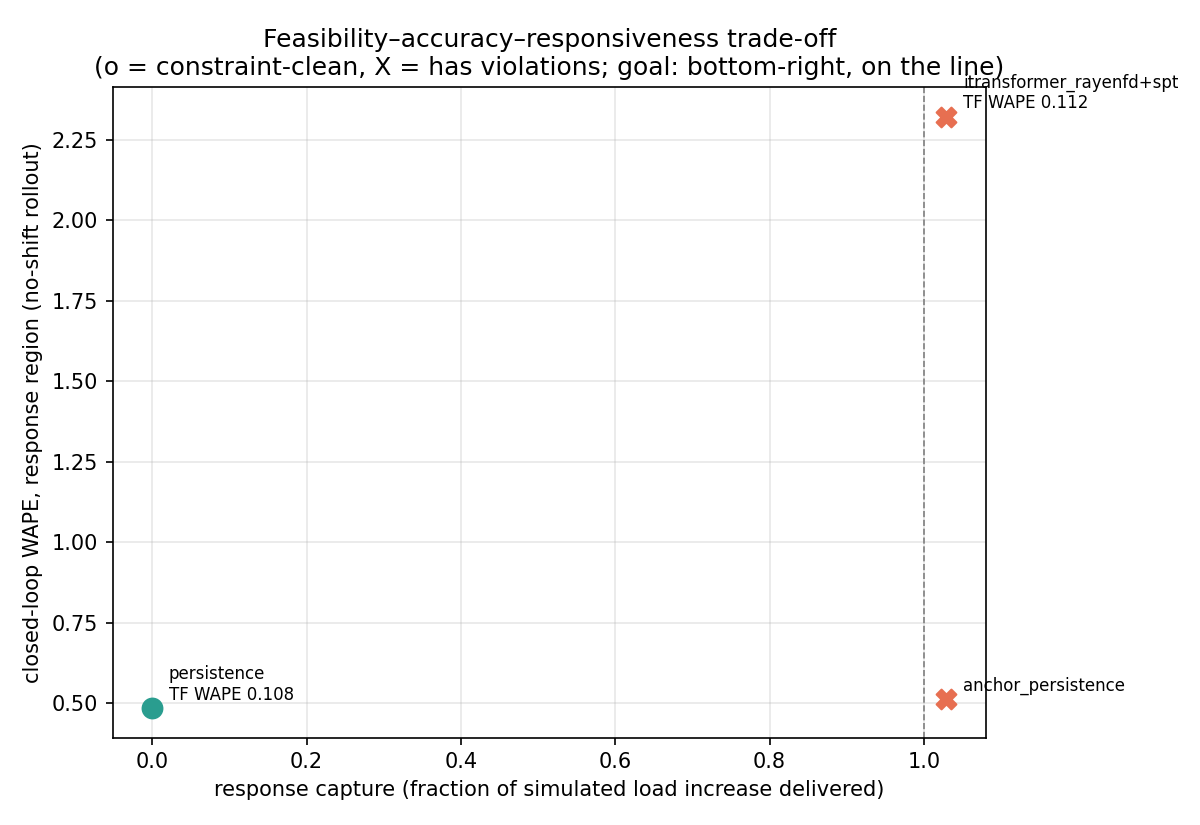

In [9]:
!python constraints/study_report.py
display(Markdown(open("constraints/results/study_summary.md").read()))
from IPython.display import Image
Image("constraints/results/figure/study_tradeoff.png")


In [10]:
# keep the numbers: zip results (+ any retrained weights already sync to Drive via $OUT)
!zip -qr study_results.zip constraints/results demand_simulation/sweep_eqnd/study weights/*rayenfd*
try:
    from google.colab import files
    files.download("study_results.zip")
except Exception:
    print("study_results.zip written")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>